In [8]:
# --- CÉLULA 1: SETUP E CARREGAMENTO ---
import os, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imports de ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, learning_curve

# Configurações
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("--- Iniciando Notebook 02 ---")

# Detectar ambiente: Colab ou Local
NO_COLAB = os.path.exists('/content')

if NO_COLAB:
    # No Colab: clonar repo do GitHub
    repo_dir = '/content/tcc-analise-sentimento'
    if os.path.exists(repo_dir):
        print("Repo já existe, atualizando...")
        subprocess.run(['git', '-C', repo_dir, 'pull'], check=True)
    else:
        print("Clonando repositório...")
        subprocess.run(['git', 'clone',
            'https://github.com/ROMAUSKI/tcc-analise-sentimento.git',
            repo_dir], check=True)
    base_dir = repo_dir
else:
    # Local (VS Code): usar caminho relativo ao notebook
    base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f"Executando localmente. Base: {base_dir}")

# Carregar dados
caminho_csv = os.path.join(base_dir, 'dados', 'processado', 'synthetic_dataset.csv')

try:
    df = pd.read_csv(caminho_csv)
    df = df.dropna(subset=['frase_limpa'])

    X = df['frase_limpa']
    y = df['classe']

    print(f"\n✅ Sucesso! Dataset carregado com {len(df)} linhas.")
    print("X e y definidos.")

except FileNotFoundError:
    print(f"\n❌ ERRO: Não encontrei o arquivo em: {caminho_csv}")
    print("Verifique a estrutura de pastas do projeto.")
except Exception as e:
    print(f"\n❌ Ocorreu um erro: {e}")

--- Iniciando Notebook 02 ---
Executando localmente. Base: c:\Users\Davi\Documents\TCC\tcc-analise-sentimento

✅ Sucesso! Dataset carregado com 1798 linhas.
X e y definidos.


In [9]:
# --- CÉLULA 2: VALIDAÇÃO CRUZADA (Accuracy + F1-Score) ---
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Pipeline base: TF-IDF + Classificador
def criar_pipeline(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000)),
        ('clf', clf)
    ])

# Definir experimentos: (nome, classificador, k)
experimentos = [
    ('Naive Bayes (k=5)',  MultinomialNB(), 5),
    ('Naive Bayes (k=10)', MultinomialNB(), 10),
    ('Regressão Logística (k=5)',  LogisticRegression(max_iter=1000), 5),
    ('Regressão Logística (k=10)', LogisticRegression(max_iter=1000), 10),
]

# Executar e armazenar resultados
resultados = []

print("=" * 65)
print("  VALIDAÇÃO CRUZADA — Accuracy e F1-Score por experimento")
print("=" * 65)

for nome, clf, k in experimentos:
    pipe_acc = criar_pipeline(clf)
    pipe_f1  = criar_pipeline(clf)

    scores_acc = cross_val_score(pipe_acc, X, y, cv=k, scoring='accuracy')
    scores_f1  = cross_val_score(pipe_f1,  X, y, cv=k, scoring='f1_weighted')

    acc_pct = scores_acc * 100
    f1_pct  = scores_f1  * 100

    resultados.append({
        'Modelo': nome,
        'k': k,
        'Acc Média': scores_acc.mean(),
        'Acc DP': scores_acc.std(),
        'F1 Média': scores_f1.mean(),
        'F1 DP': scores_f1.std(),
        'Scores Acc': scores_acc,
        'Scores F1': scores_f1
    })

    folds_acc = ', '.join([f"{s:.2f}%" for s in acc_pct])
    folds_f1  = ', '.join([f"{s:.2f}%" for s in f1_pct])

    print(f"\n📌 {nome}")
    print(f"   Accuracy — Folds: [{folds_acc}]")
    print(f"              Média: {acc_pct.mean():.6f}% ± {acc_pct.std():.6f}%")
    print(f"   F1-Score — Folds: [{folds_f1}]")
    print(f"              Média: {f1_pct.mean():.6f}% ± {f1_pct.std():.6f}%")

    # Legenda curta
    if acc_pct.std() < 1.0:
        print(f"   → Modelo estável (baixa variância).")
    elif acc_pct.std() < 2.0:
        print(f"   → Desempenho consistente (variância moderada).")
    else:
        print(f"   → Desempenho oscila entre folds (alta variância).")

print("\n" + "=" * 65)

# Resumo em DataFrame
df_cv = pd.DataFrame([{
    'Modelo': r['Modelo'],
    'k': r['k'],
    'Accuracy Média (%)': f"{r['Acc Média'] * 100:.6f}",
    'Accuracy DP (%)': f"{r['Acc DP'] * 100:.6f}",
    'F1-Score Média (%)': f"{r['F1 Média'] * 100:.6f}",
    'F1-Score DP (%)': f"{r['F1 DP'] * 100:.6f}"
} for r in resultados])

print("\n📊 Resumo da Validação Cruzada:")
print(df_cv.to_string(index=False))
print("\nLegenda: Accuracy = taxa de acertos; F1 = média ponderada de precisão e recall; DP = desvio padrão entre folds.")

  VALIDAÇÃO CRUZADA — Accuracy e F1-Score por experimento

📌 Naive Bayes (k=5)
   Accuracy — Folds: [89.17%, 88.33%, 88.33%, 89.42%, 90.25%]
              Média: 89.099814% ± 0.721575%
   F1-Score — Folds: [89.16%, 88.33%, 88.35%, 89.42%, 90.29%]
              Média: 89.107628% ± 0.731193%
   → Modelo estável (baixa variância).

📌 Naive Bayes (k=10)
   Accuracy — Folds: [91.11%, 87.78%, 87.22%, 87.22%, 88.89%, 91.11%, 91.11%, 87.78%, 87.15%, 91.62%]
              Média: 89.099317% ± 1.813204%
   F1-Score — Folds: [91.08%, 87.77%, 87.15%, 87.24%, 88.98%, 91.07%, 91.14%, 87.77%, 87.16%, 91.69%]
              Média: 89.105894% ± 1.823337%
   → Desempenho consistente (variância moderada).

📌 Regressão Logística (k=5)
   Accuracy — Folds: [88.06%, 87.78%, 88.89%, 85.24%, 85.24%]
              Média: 87.039152% ± 1.516400%
   F1-Score — Folds: [88.06%, 87.68%, 88.89%, 85.21%, 85.14%]
              Média: 86.995631% ± 1.537905%
   → Desempenho consistente (variância moderada).

📌 Regressão Lo

In [10]:
# --- CÉLULA 3: SALVAR RESULTADOS EM CSV ---
# Diretório de resultados (compatível Colab/Local)
dir_resultados = os.path.join(base_dir, 'resultados')
os.makedirs(dir_resultados, exist_ok=True)

# Salvar tabela comparativa
caminho_csv_resultado = os.path.join(dir_resultados, 'validacao_cruzada.csv')
df_cv.to_csv(caminho_csv_resultado, index=False)

print(f"✅ Tabela salva em: {caminho_csv_resultado}")
print(f"\n{df_cv.to_string(index=False)}")

✅ Tabela salva em: c:\Users\Davi\Documents\TCC\tcc-analise-sentimento\resultados\validacao_cruzada.csv

                    Modelo  k Accuracy Média (%) Accuracy DP (%) F1-Score Média (%) F1-Score DP (%)
         Naive Bayes (k=5)  5          89.099814        0.721575          89.107628        0.731193
        Naive Bayes (k=10) 10          89.099317        1.813204          89.105894        1.823337
 Regressão Logística (k=5)  5          87.039152        1.516400          86.995631        1.537905
Regressão Logística (k=10) 10          87.596214        2.703767          87.532606        2.779426


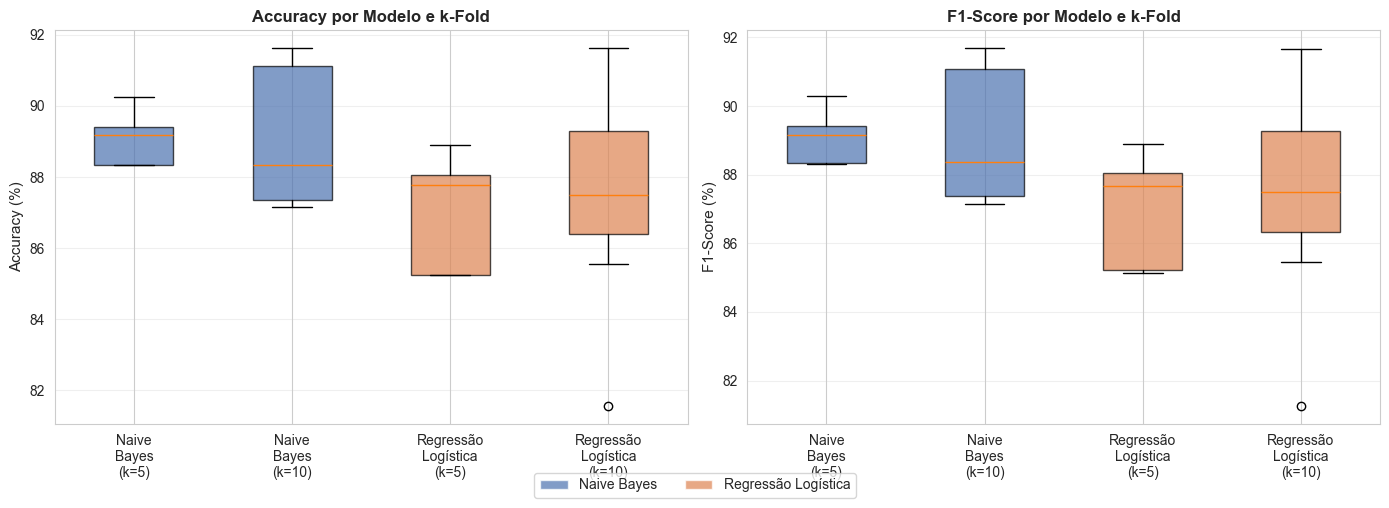


✅ Gráfico salvo em: c:\Users\Davi\Documents\TCC\tcc-analise-sentimento\resultados\boxplot_validacao_cruzada.png


In [11]:
# --- CÉLULA 4: BOXPLOT COMPARATIVO DOS K-FOLDS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Preparar dados para boxplot
dados_acc = {r['Modelo']: r['Scores Acc'] * 100 for r in resultados}
dados_f1  = {r['Modelo']: r['Scores F1']  * 100 for r in resultados}

# --- Boxplot Accuracy ---
ax1 = axes[0]
bp1 = ax1.boxplot(dados_acc.values(), labels=[n.replace(' ', '\n') for n in dados_acc.keys()],
                   patch_artist=True, widths=0.5)
cores = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']
for patch, cor in zip(bp1['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax1.set_title('Accuracy por Modelo e k-Fold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# --- Boxplot F1-Score ---
ax2 = axes[1]
bp2 = ax2.boxplot(dados_f1.values(), labels=[n.replace(' ', '\n') for n in dados_f1.keys()],
                   patch_artist=True, widths=0.5)
for patch, cor in zip(bp2['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax2.set_title('F1-Score por Modelo e k-Fold', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1-Score (%)', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# Legenda manual
from matplotlib.patches import Patch
legenda = [Patch(facecolor='#4C72B0', alpha=0.7, label='Naive Bayes'),
           Patch(facecolor='#DD8452', alpha=0.7, label='Regressão Logística')]
fig.legend(handles=legenda, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()

# Salvar
caminho_boxplot = os.path.join(dir_resultados, 'boxplot_validacao_cruzada.png')
fig.savefig(caminho_boxplot, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Gráfico salvo em: {caminho_boxplot}")